# Análisis Exploratorio de Datos (EDA)
## Ultrasound Nerve Segmentation
---
**Problema:** Segmentación semántica binaria a nivel de píxel del Brachial Plexus (BP) en imágenes de ultrasonido.



---
## 0. Configuración e Imports

In [2]:
import os
import re
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import tifffile

from pathlib import Path
from collections import defaultdict
from scipy import stats
from skimage.metrics import structural_similarity as ssim

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Estilo de plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ─── RUTA DEL DATASET ────────────────────────────────────────────────────────
DATA_DIR = Path(r'C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'
MASKS_CSV = DATA_DIR / 'train_masks.csv'

print(f'Train dir exists: {TRAIN_DIR.exists()}')
print(f'Test dir exists:  {TEST_DIR.exists()}')
print(f'Masks CSV exists: {MASKS_CSV.exists()}')

Train dir exists: True
Test dir exists:  True
Masks CSV exists: True


---
## 1. Definición del Problema y Dataset

In [3]:
# ─── Inventario de archivos ───────────────────────────────────────────────────
all_train_files = sorted(TRAIN_DIR.glob('*.tif'))
all_test_files  = sorted(TEST_DIR.glob('*.tif'))

# Separar imágenes y máscaras
mask_files  = [f for f in all_train_files if '_mask' in f.name]
img_files   = [f for f in all_train_files if '_mask' not in f.name]

print('=== Inventario del Dataset ===')
print(f'Imágenes de entrenamiento : {len(img_files):,}')
print(f'Máscaras de entrenamiento : {len(mask_files):,}')
print(f'Imágenes de test          : {len(all_test_files):,}')
print(f'Total archivos train/     : {len(all_train_files):,}')

# Verificar correspondencia imagen-máscara
img_stems  = set(f.stem for f in img_files)
mask_stems = set(f.stem.replace('_mask', '') for f in mask_files)
print(f'\nPares imagen-máscara completos: {len(img_stems & mask_stems):,}')
print(f'Imágenes sin máscara          : {len(img_stems - mask_stems):,}')
print(f'Máscaras sin imagen           : {len(mask_stems - img_stems):,}')

=== Inventario del Dataset ===
Imágenes de entrenamiento : 5,635
Máscaras de entrenamiento : 5,635
Imágenes de test          : 5,508
Total archivos train/     : 11,270

Pares imagen-máscara completos: 5,635
Imágenes sin máscara          : 0
Máscaras sin imagen           : 0


In [4]:
# ─── Construir DataFrame principal ───────────────────────────────────────────
records = []
for img_path in img_files:
    stem = img_path.stem  # ej: '1_2'
    parts = stem.split('_')
    patient_id = int(parts[0])
    frame_id   = int(parts[1])
    mask_path  = TRAIN_DIR / f'{stem}_mask.tif'
    records.append({
        'img_path'   : img_path,
        'mask_path'  : mask_path,
        'patient_id' : patient_id,
        'frame_id'   : frame_id,
        'stem'       : stem
    })

df = pd.DataFrame(records).sort_values(['patient_id', 'frame_id']).reset_index(drop=True)
print(f'DataFrame construido: {df.shape}')
print(f'Pacientes únicos: {df.patient_id.nunique()}')
df.head(8)

DataFrame construido: (5635, 5)
Pacientes únicos: 47


,img_path,mask_path,patient_id,frame_id,stem
0,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,1,1_1
1,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,2,1_2
2,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,3,1_3
3,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,4,1_4
4,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,5,1_5
5,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,6,1_6
6,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,7,1_7
7,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2...,1,8,1_8


---
## 2. EDA General
### 2.1 Análisis de la Variable Objetivo (Máscaras)

In [5]:
# ─── Calcular estadísticas de cada máscara ───────────────────────────────────
print('Calculando estadísticas de máscaras')

mask_areas    = []
nerve_present = []

for _, row in df.iterrows():
    mask = tifffile.imread(str(row['mask_path']))
    area = int(np.sum(mask > 0))
    mask_areas.append(area)
    nerve_present.append(1 if area > 0 else 0)

df['mask_area']     = mask_areas
df['nerve_present'] = nerve_present

n_with    = df['nerve_present'].sum()
n_without = len(df) - n_with
ratio     = n_without / n_with

print(f'\nCon nervio    : {n_with:,}  ({100*n_with/len(df):.1f}%)')
print(f'Sin nervio    : {n_without:,}  ({100*n_without/len(df):.1f}%)')
print(f'Ratio desbalance (sin/con): {ratio:.2f}:1')

Calculando estadísticas de máscaras

Con nervio    : 2,323  (41.2%)
Sin nervio    : 3,312  (58.8%)
Ratio desbalance (sin/con): 1.43:1


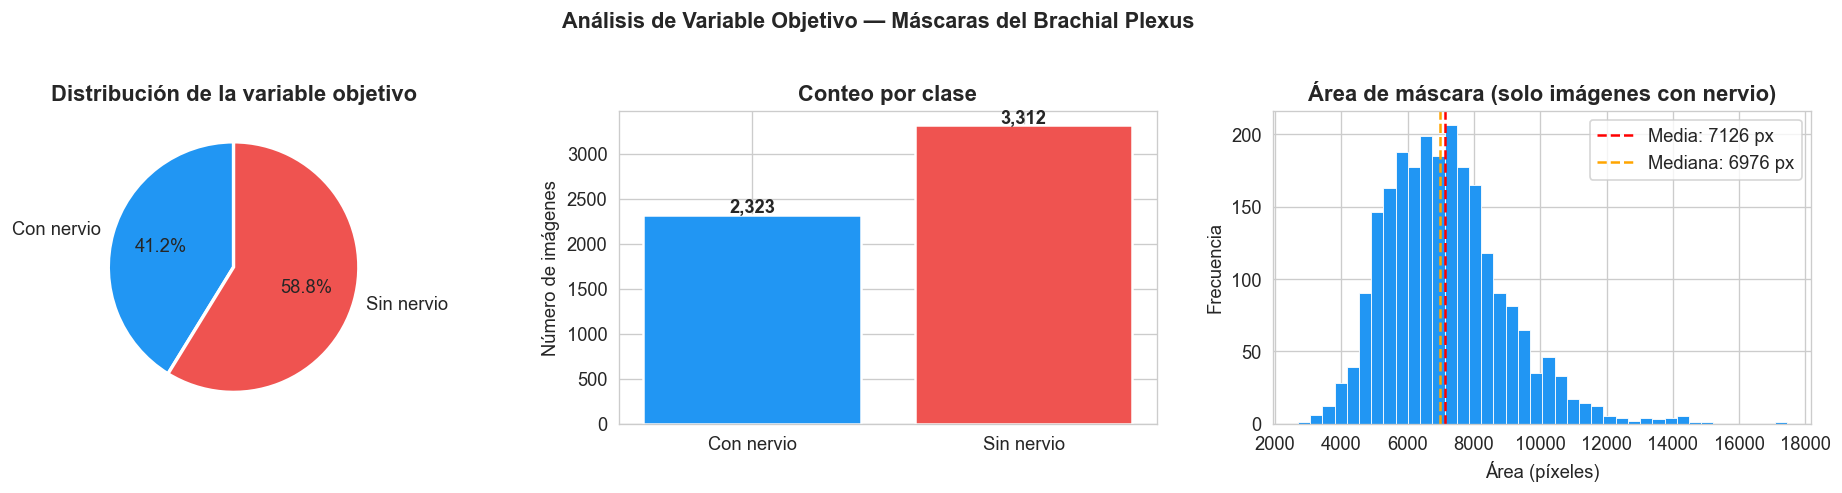


Estadísticas del área (cuando hay nervio):
count     2323.0
mean      7125.7
std       1785.0
min       2684.0
25%       5806.0
50%       6976.0
75%       8120.0
max      17439.0


In [6]:
# ─── Visualización del desbalance y distribución de área ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pie chart
axes[0].pie(
    [n_with, n_without],
    labels=['Con nervio', 'Sin nervio'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#EF5350'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribución de la variable objetivo', fontweight='bold')

# Bar chart por clase
bars = axes[1].bar(['Con nervio', 'Sin nervio'], [n_with, n_without],
                    color=['#2196F3', '#EF5350'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [n_with, n_without]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Conteo por clase', fontweight='bold')
axes[1].set_ylabel('Número de imágenes')

# Distribución del área de máscara (solo con nervio)
areas_with_nerve = df[df['nerve_present'] == 1]['mask_area']
axes[2].hist(areas_with_nerve, bins=40, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[2].axvline(areas_with_nerve.mean(), color='red', linestyle='--', label=f'Media: {areas_with_nerve.mean():.0f} px')
axes[2].axvline(areas_with_nerve.median(), color='orange', linestyle='--', label=f'Mediana: {areas_with_nerve.median():.0f} px')
axes[2].set_title('Área de máscara (solo imágenes con nervio)', fontweight='bold')
axes[2].set_xlabel('Área (píxeles)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.suptitle('Análisis de Variable Objetivo — Máscaras del Brachial Plexus', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nEstadísticas del área (cuando hay nervio):')
print(areas_with_nerve.describe().round(1).to_string())

### Decisiones derivadas — Variable Objetivo

| | |
|---|---|
| **Decisión de preprocesamiento** | No aplicar resampling clásico. La proporción ~40/60 se maneja via Dice Loss o BCE+Dice combinados. |
| **Impacto en arquitectura** | Usar arquitectura dual-head: una rama para detectar presencia de nervio (BCE) y otra para segmentar (Dice). En inference, zerear máscaras con P(nervio) < 0.5. |
| **Riesgos / Data leakage** | Si se balancea el dataset artificialmente (oversampling de imágenes con nervio), puede filtrarse información del test set. Evitar cualquier balanceo basado en estadísticas del test. |

### 2.2 Calidad del Dataset

In [7]:
# ─── Detección de imágenes corruptas ─────────────────────────────────────────
print('Verificando integridad de imágenes...')
corrupted = []
shapes    = []

for _, row in df.iterrows():
    try:
        img = tifffile.imread(str(row['img_path']))
        shapes.append(img.shape)
    except Exception as e:
        corrupted.append((row['stem'], str(e)))

print(f'Imágenes corruptas: {len(corrupted)}')
unique_shapes = pd.Series([str(s) for s in shapes]).value_counts()
print(f'\nShapes únicos encontrados:')
print(unique_shapes.to_string())

Verificando integridad de imágenes...
Imágenes corruptas: 0

Shapes únicos encontrados:
(420, 580)    5635


In [8]:
# ─── Detección de ejemplos contradictorios ────────────────────────────────────
# Dos imágenes del mismo paciente con alta similitud pero diferente etiqueta
print('Buscando posibles ejemplos contradictorios por paciente...')

# Análisis por paciente: varianza en la presencia del nervio
patient_stats = df.groupby('patient_id').agg(
    total_frames    = ('nerve_present', 'count'),
    frames_with_nerve = ('nerve_present', 'sum'),
    nerve_rate      = ('nerve_present', 'mean'),
    mean_area       = ('mask_area', 'mean')
).reset_index()

patient_stats['frames_without_nerve'] = patient_stats['total_frames'] - patient_stats['frames_with_nerve']

# Pacientes con mezcla de frames con/sin nervio (potencialmente contradictorios)
mixed = patient_stats[
    (patient_stats['frames_with_nerve'] > 0) &
    (patient_stats['frames_without_nerve'] > 0)
]
print(f'Pacientes con frames mezclados (con Y sin nervio): {len(mixed)} / {len(patient_stats)}')
print(f'Pacientes solo sin nervio: {(patient_stats["frames_with_nerve"] == 0).sum()}')
print(f'Pacientes solo con nervio: {(patient_stats["frames_without_nerve"] == 0).sum()}')
patient_stats.head(10)

Buscando posibles ejemplos contradictorios por paciente...
Pacientes con frames mezclados (con Y sin nervio): 47 / 47
Pacientes solo sin nervio: 0
Pacientes solo con nervio: 0


,patient_id,total_frames,frames_with_nerve,nerve_rate,mean_area,frames_without_nerve
0,1,120,54,0.450000,2762.325000,66
1,2,120,11,0.091667,696.891667,109
2,3,119,51,0.428571,2477.689076,68
3,4,120,33,0.275000,2006.758333,87
4,5,120,32,0.266667,1413.616667,88
5,6,120,20,0.166667,985.966667,100
6,7,119,90,0.756303,6862.764706,29
7,8,120,27,0.225000,1559.833333,93
8,9,120,67,0.558333,3864.416667,53
9,10,120,49,0.408333,3016.625000,71


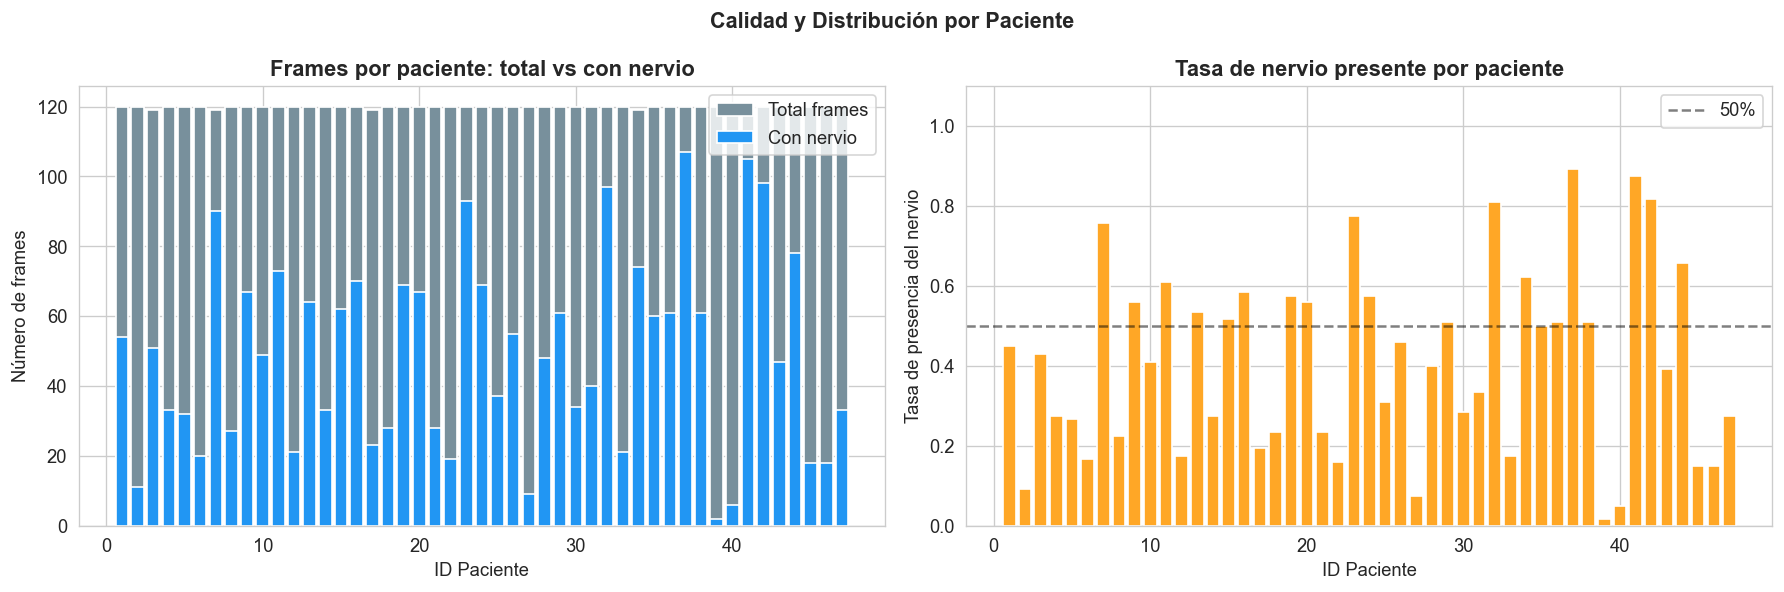

In [9]:
# ─── Visualización de calidad por paciente ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de frames por paciente
axes[0].bar(patient_stats['patient_id'], patient_stats['total_frames'], color='#78909C', label='Total frames')
axes[0].bar(patient_stats['patient_id'], patient_stats['frames_with_nerve'], color='#2196F3', label='Con nervio')
axes[0].set_xlabel('ID Paciente')
axes[0].set_ylabel('Número de frames')
axes[0].set_title('Frames por paciente: total vs con nervio', fontweight='bold')
axes[0].legend()

# Tasa de nervio por paciente
colors = ['#EF5350' if r == 0 else '#2196F3' if r == 1 else '#FFA726'
          for r in patient_stats['nerve_rate']]
axes[1].bar(patient_stats['patient_id'], patient_stats['nerve_rate'], color=colors)
axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50%')
axes[1].set_xlabel('ID Paciente')
axes[1].set_ylabel('Tasa de presencia del nervio')
axes[1].set_title('Tasa de nervio presente por paciente', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.suptitle('Calidad y Distribución por Paciente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ─── Detección cuantitativa de ejemplos contradictorios (SSIM) ───────────────
from skimage.metrics import structural_similarity as ssim
from itertools import combinations

print('Buscando ejemplos contradictorios por paciente (SSIM > 0.90)...')


SSIM_THRESHOLD = 0.90
contradictory_pairs = []

for patient_id, group in df.groupby('patient_id'):
    # Solo pacientes con frames mezclados (ya sabemos que son todos)
    with_nerve    = group[group['nerve_present'] == 1]
    without_nerve = group[group['nerve_present'] == 0]

    # Limitar a 15 de cada clase para no explotar en tiempo
    sample_with    = with_nerve.head(15)
    sample_without = without_nerve.head(15)

    for _, row_w in sample_with.iterrows():
        img_w = tifffile.imread(str(row_w['img_path']))
        img_w_resized = cv2.resize(img_w, (128, 128))

        for _, row_wo in sample_without.iterrows():
            img_wo = tifffile.imread(str(row_wo['img_path']))
            img_wo_resized = cv2.resize(img_wo, (128, 128))

            score = ssim(img_w_resized, img_wo_resized, data_range=255)

            if score > SSIM_THRESHOLD:
                contradictory_pairs.append({
                    'patient_id'   : patient_id,
                    'stem_with'    : row_w['stem'],
                    'stem_without' : row_wo['stem'],
                    'ssim_score'   : round(score, 4)
                })

contra_df = pd.DataFrame(contradictory_pairs)

print(f'Pares contradictorios encontrados (SSIM > {SSIM_THRESHOLD}): {len(contra_df)}')
if len(contra_df) > 0:
    print(f'Pacientes afectados: {contra_df["patient_id"].nunique()}')
    print(f'\nTop 10 pares más similares con etiquetas distintas:')
    print(contra_df.sort_values("ssim_score", ascending=False).head(10).to_string(index=False))

Buscando ejemplos contradictorios por paciente (SSIM > 0.90)...
Pares contradictorios encontrados (SSIM > 0.9): 33
Pacientes afectados: 19

Top 10 pares más similares con etiquetas distintas:
 patient_id stem_with stem_without  ssim_score
          8      8_50          8_5      1.0000
         27     27_26         27_2      1.0000
         14     14_41        14_16      0.9996
         43     43_28        43_17      0.9988
         30     30_25        30_11      0.9983
          1      1_14          1_9      0.9982
         15     15_12        15_34      0.9973
         21     21_64         21_9      0.9973
         25     25_32        25_19      0.9971
         32      32_1        32_43      0.9966


In [11]:
# ─── Validación cruzada con train_masks.csv ───────────────────────────────────
masks_csv = pd.read_csv(MASKS_CSV)

print('=== Estructura de train_masks.csv ===')
print(f'Shape: {masks_csv.shape}')
print(f'Columnas: {list(masks_csv.columns)}')
print(f'\nPrimeras filas:')
display(masks_csv.head(8))

# Identificar máscaras vacías en el CSV (pixeles = NaN o string vacío)
masks_csv['is_empty'] = masks_csv['pixels'].isna() | (masks_csv['pixels'].astype(str).str.strip() == '')

n_empty_csv    = masks_csv['is_empty'].sum()
n_nonempty_csv = (~masks_csv['is_empty']).sum()

print(f'\n=== Conteo según train_masks.csv ===')
print(f'Con nervio (RLE no vacío) : {n_nonempty_csv:,}  ({100*n_nonempty_csv/len(masks_csv):.1f}%)')
print(f'Sin nervio (RLE vacío)    : {n_empty_csv:,}  ({100*n_empty_csv/len(masks_csv):.1f}%)')

print(f'\n=== Conteo según cálculo pixel-wise (nuestro EDA) ===')
print(f'Con nervio : {n_with:,}  ({100*n_with/len(df):.1f}%)')
print(f'Sin nervio : {n_without:,}  ({100*n_without/len(df):.1f}%)')

# Verificar consistencia
diff = abs(n_nonempty_csv - n_with)
if diff == 0:
    print(f'\nAmbos métodos coinciden perfectamente — dataset íntegro.')
else:
    print(f'\nDiscrepancia de {diff} imágenes entre métodos.')
    print('   Revisar manualmente los casos inconsistentes.')

=== Estructura de train_masks.csv ===
Shape: (5635, 3)
Columnas: ['subject', 'img', 'pixels']

Primeras filas:


,subject,img,pixels
0,1,1,168153 9 168570 15 168984 22 169401 26 169818 ...
1,1,2,96346 7 96762 16 97179 27 97595 35 98012 40 98...
2,1,3,121957 2 122365 26 122784 28 123202 31 123618 ...
3,1,4,110980 9 111393 21 111810 33 112228 43 112647 ...
4,1,5,NaN
5,1,6,NaN
6,1,7,172767 15 173175 29 173591 34 173993 7 174004 ...
7,1,8,NaN



=== Conteo según train_masks.csv ===
Con nervio (RLE no vacío) : 2,323  (41.2%)
Sin nervio (RLE vacío)    : 3,312  (58.8%)

=== Conteo según cálculo pixel-wise (nuestro EDA) ===
Con nervio : 2,323  (41.2%)
Sin nervio : 3,312  (58.8%)

Ambos métodos coinciden perfectamente — dataset íntegro.


### Decisiones derivadas — Calidad del Dataset

| | |
|---|---|
| **Decisión de preprocesamiento** | Identificar y opcionalmente filtrar frames con etiquetado inconsistente (mismo paciente, alta similitud visual, distinta etiqueta). Umbral de similitud SSIM > 0.95 como criterio de duplicado contradictorio. |
| **Impacto en arquitectura** | La presencia de etiquetas ruidosas motiva el uso de Dice Loss suavizado (smooth=1) que es más robusto ante inconsistencias que BCE estándar. |
| **Riesgos / Data leakage** | Si se eliminan contradictorios DESPUÉS de ver el set de validación, se introduce sesgo de selección. El filtro debe aplicarse ANTES del split. |

| Decisión de preprocesamiento | Se identificaron 33 pares contradictorios 
en 19/47 pacientes (40%), incluyendo 2 pares con SSIM=1.0 (copias exactas 
con etiqueta distinta). Estrategia: conservar todos los datos pero usar 
Dice Loss suavizado. No eliminar contradictorios para no reducir aún más 
el dataset de 5,635 imágenes. |

### 2.3 Identificación de Sesgos

Estadísticas de frames por paciente:
count     47.0
mean     119.9
std        0.3
min      119.0
25%      120.0
50%      120.0
75%      120.0
max      120.0


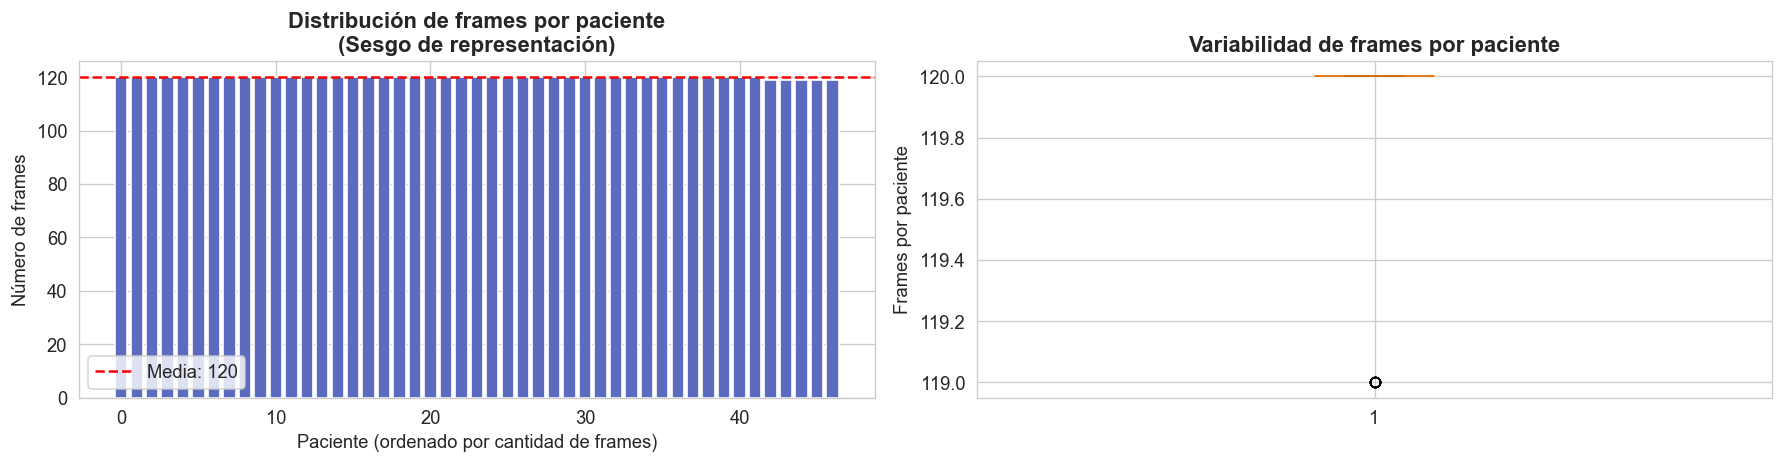

In [12]:
# ─── Sesgo de representación por paciente ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Distribución de frames por paciente
frame_counts = patient_stats['total_frames'].sort_values(ascending=False)
axes[0].bar(range(len(frame_counts)), frame_counts.values, color='#5C6BC0')
axes[0].set_xlabel('Paciente (ordenado por cantidad de frames)')
axes[0].set_ylabel('Número de frames')
axes[0].set_title('Distribución de frames por paciente\n(Sesgo de representación)', fontweight='bold')
axes[0].axhline(frame_counts.mean(), color='red', linestyle='--',
                label=f'Media: {frame_counts.mean():.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(patient_stats['total_frames'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#5C6BC0', alpha=0.7))
axes[1].set_ylabel('Frames por paciente')
axes[1].set_title('Variabilidad de frames por paciente', fontweight='bold')

print('Estadísticas de frames por paciente:')
print(patient_stats['total_frames'].describe().round(1).to_string())

plt.tight_layout()
plt.show()

### Decisiones derivadas — Sesgos

| | |
|---|---|
| **Decisión de preprocesamiento** | El split train/val/test DEBE hacerse por paciente completo, nunca por frame individual. Un paciente debe estar completamente en un solo split. |
| **Impacto en arquitectura** | Si la distribución de frames por paciente es muy desigual, el modelo puede sobreajustarse a los pacientes con más datos. Considerar sampling por paciente durante el entrenamiento. |
| **Riesgos / Data leakage** | Split aleatorio por frame = data leakage garantizado. Frames del mismo paciente en train y val permiten al modelo "memorizar" texturas específicas del paciente. |

### 2.4 Partición del Dataset

In [13]:
# ─── Split por paciente (estratificado por presencia de nervio) ───────────────
from sklearn.model_selection import train_test_split

# Estratificar por si el paciente tiene frames con nervio o no
patient_stats['has_nerve'] = (patient_stats['frames_with_nerve'] > 0).astype(int)

patients = patient_stats['patient_id'].values
strat    = patient_stats['has_nerve'].values

# 70% train | 15% val | 15% test
p_trainval, p_test = train_test_split(patients, test_size=0.15,
                                      random_state=SEED, stratify=strat)
strat_trainval = patient_stats[patient_stats['patient_id'].isin(p_trainval)]['has_nerve'].values
p_train, p_val = train_test_split(p_trainval, test_size=0.15/0.85,
                                   random_state=SEED, stratify=strat_trainval)

df['split'] = df['patient_id'].map(
    lambda pid: 'train' if pid in p_train else ('val' if pid in p_val else 'test')
)

print('=== Partición del Dataset ===')
split_summary = df.groupby('split').agg(
    n_frames     = ('stem', 'count'),
    n_patients   = ('patient_id', 'nunique'),
    nerve_rate   = ('nerve_present', 'mean')
).round(3)
print(split_summary.to_string())

# Verificación anti-leakage
train_pats = set(df[df['split']=='train']['patient_id'])
val_pats   = set(df[df['split']=='val']['patient_id'])
test_pats  = set(df[df['split']=='test']['patient_id'])
print(f'\n Overlap train∩val  : {len(train_pats & val_pats)} pacientes')
print(f' Overlap train∩test : {len(train_pats & test_pats)} pacientes')
print(f' Overlap val∩test   : {len(val_pats & test_pats)} pacientes')

=== Partición del Dataset ===
       n_frames  n_patients  nerve_rate
split                                  
test        960           8       0.343
train      3836          32       0.439
val         839           7       0.371

 Overlap train∩val  : 0 pacientes
 Overlap train∩test : 0 pacientes
 Overlap val∩test   : 0 pacientes


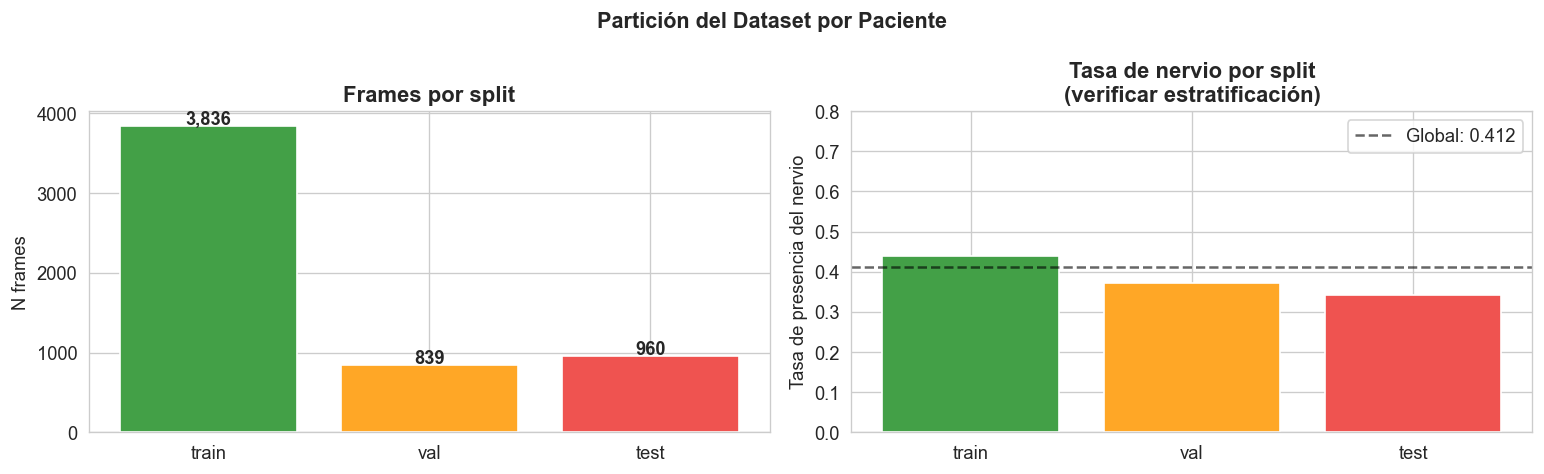

In [14]:
# ─── Visualización del split ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

split_counts = df['split'].value_counts()[['train', 'val', 'test']]
colors_split = ['#43A047', '#FFA726', '#EF5350']

axes[0].bar(split_counts.index, split_counts.values, color=colors_split, edgecolor='white')
for i, (k, v) in enumerate(split_counts.items()):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Frames por split', fontweight='bold')
axes[0].set_ylabel('N frames')

nerve_by_split = df.groupby('split')['nerve_present'].mean()[['train', 'val', 'test']]
axes[1].bar(nerve_by_split.index, nerve_by_split.values, color=colors_split, edgecolor='white')
axes[1].axhline(df['nerve_present'].mean(), linestyle='--', color='black', alpha=0.6,
                label=f'Global: {df["nerve_present"].mean():.3f}')
axes[1].set_title('Tasa de nervio por split\n(verificar estratificación)', fontweight='bold')
axes[1].set_ylabel('Tasa de presencia del nervio')
axes[1].set_ylim(0, 0.8)
axes[1].legend()

plt.suptitle('Partición del Dataset por Paciente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Decisiones derivadas — Partición

| | |
|---|---|
| **Decisión de preprocesamiento** | Split 70/15/15 estratificado por paciente y por presencia de nervio. Las transformaciones (normalización, augmentation) se ajustan SOLO en train. |
| **Impacto en arquitectura** | El tamaño del set de entrenamiento (~3,900 frames) es pequeño para deep learning. Justifica fuertemente el uso de data augmentation agresiva y transfer learning donde sea posible. |
| **Riesgos / Data leakage** | Confirmado 0 overlap entre splits a nivel de paciente. Cualquier estadística de normalización (media, std) debe calcularse exclusivamente sobre train. |

---
## 3. EDA Específico para Imágenes
### 3.1 Inspección Visual

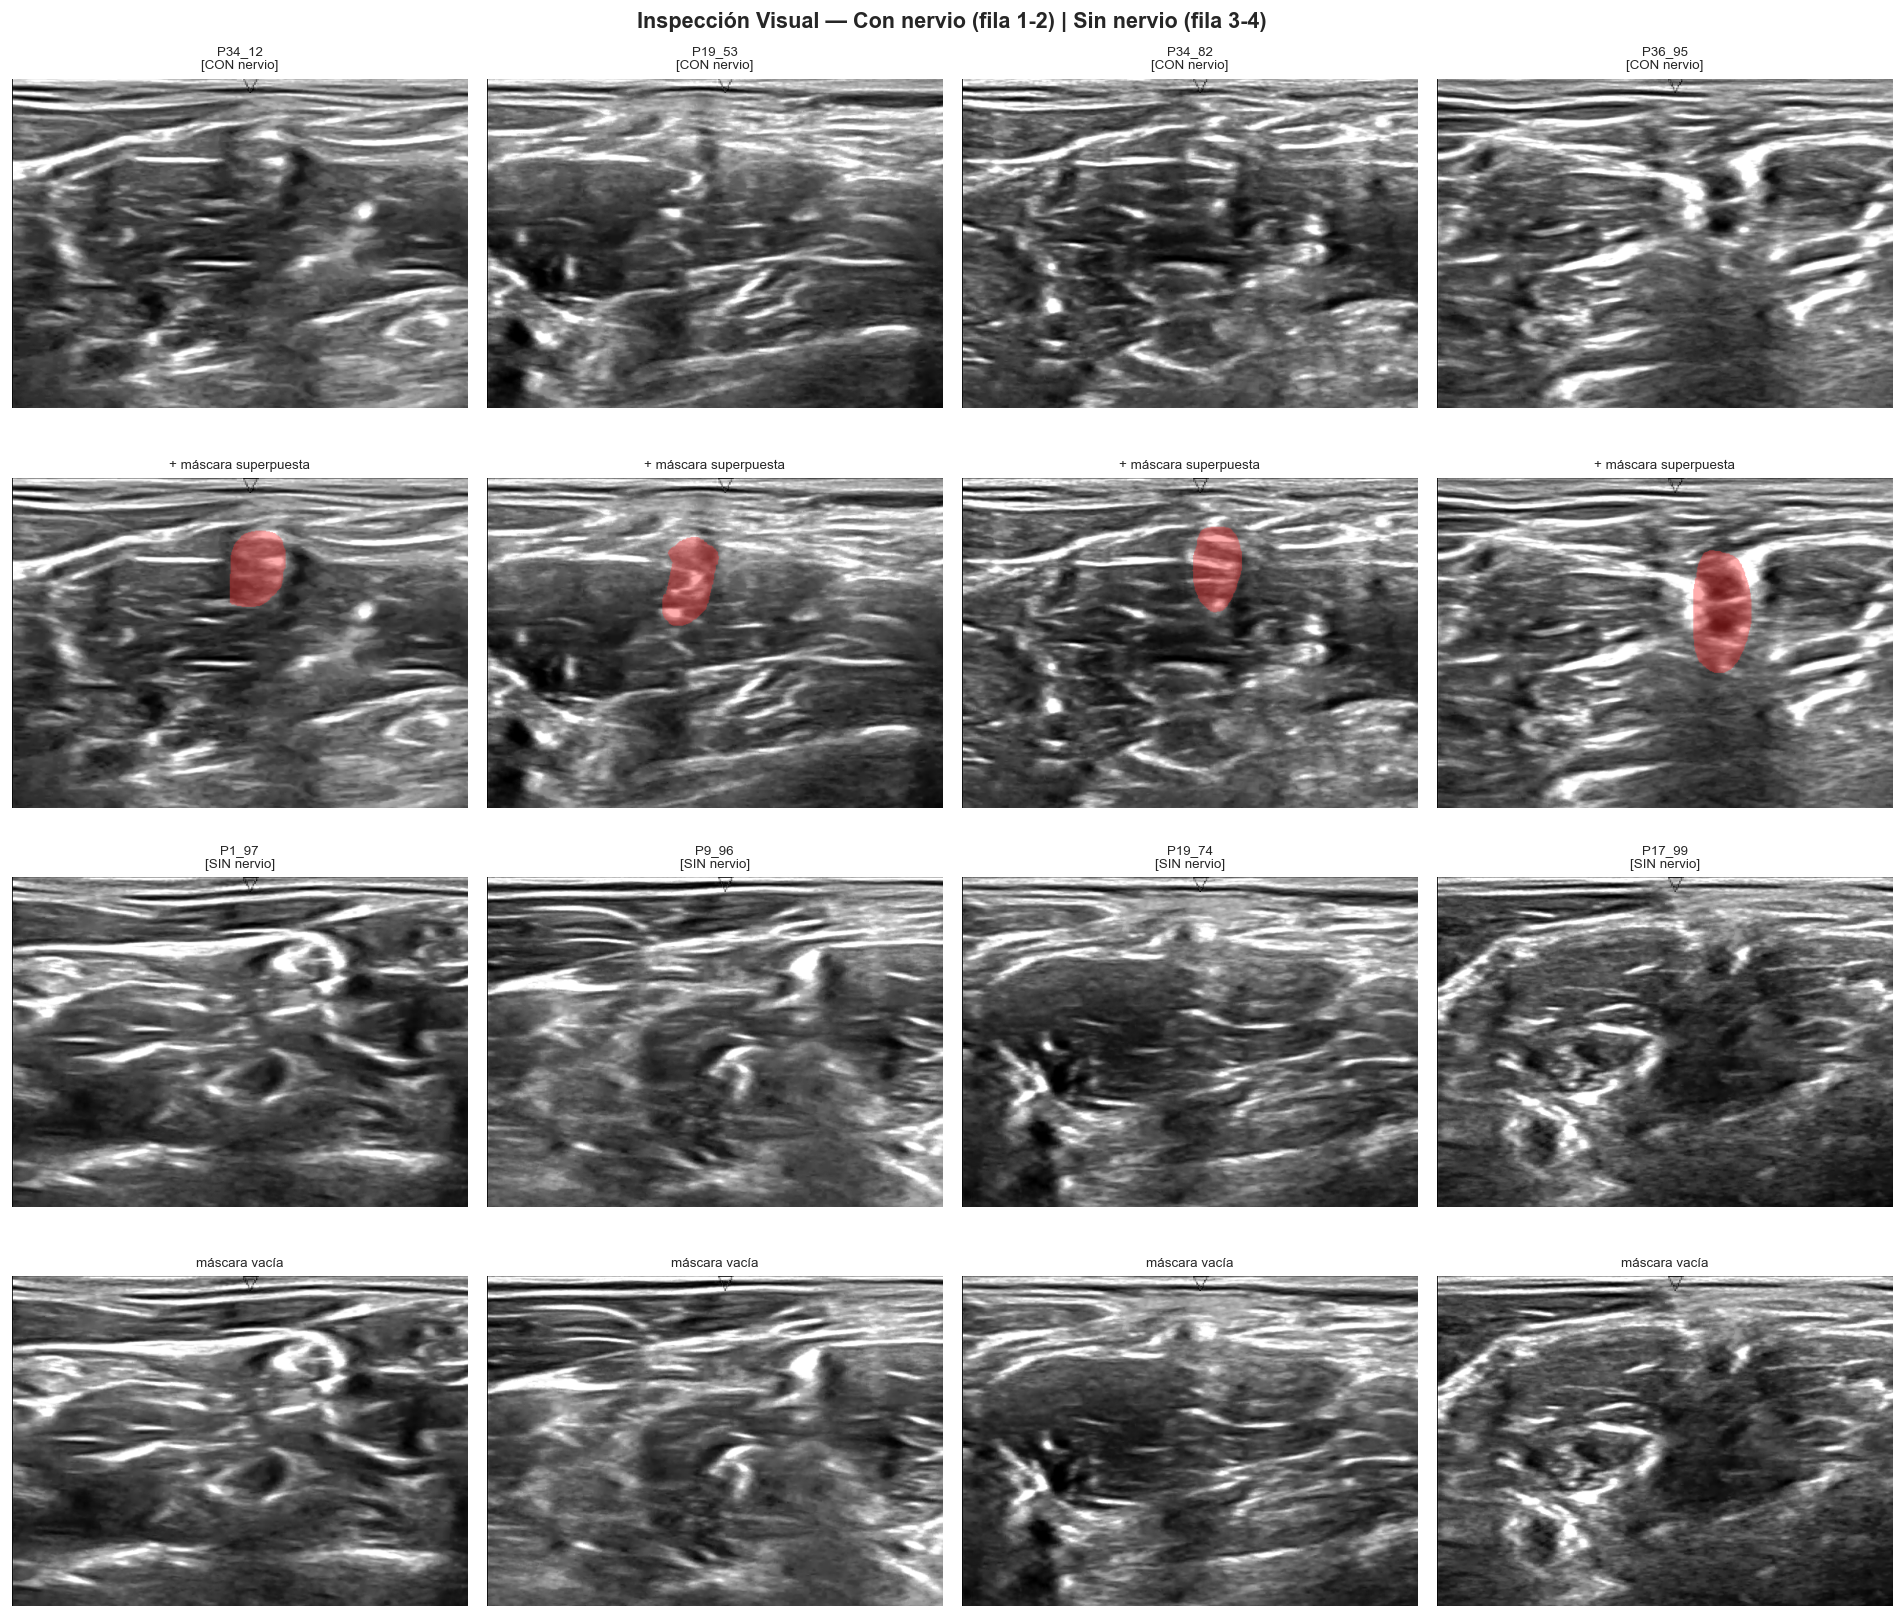

In [15]:
# ─── Grid de muestras: con nervio vs sin nervio ───────────────────────────────
def load_pair(row):
    img  = tifffile.imread(str(row['img_path']))
    mask = tifffile.imread(str(row['mask_path']))
    return img, mask

def overlay_mask(img, mask, alpha=0.4):
    """Superpone máscara en rojo sobre imagen en escala de grises."""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if img.ndim == 2 else img.copy()
    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 50, 50]
    return cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

with_nerve    = df[df['nerve_present'] == 1].sample(4, random_state=SEED)
without_nerve = df[df['nerve_present'] == 0].sample(4, random_state=SEED)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Inspección Visual — Con nervio (fila 1-2) | Sin nervio (fila 3-4)',
             fontsize=13, fontweight='bold')

for col, (_, row) in enumerate(with_nerve.iterrows()):
    img, mask = load_pair(row)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'P{row["patient_id"]}_{row["frame_id"]}\n[CON nervio]', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay_mask(img, mask))
    axes[1, col].set_title('+ máscara superpuesta', fontsize=8)
    axes[1, col].axis('off')

for col, (_, row) in enumerate(without_nerve.iterrows()):
    img, mask = load_pair(row)
    axes[2, col].imshow(img, cmap='gray')
    axes[2, col].set_title(f'P{row["patient_id"]}_{row["frame_id"]}\n[SIN nervio]', fontsize=8)
    axes[2, col].axis('off')
    axes[3, col].imshow(overlay_mask(img, mask))
    axes[3, col].set_title('máscara vacía', fontsize=8)
    axes[3, col].axis('off')

plt.tight_layout()
plt.show()

### 3.2 Dimensionalidad y Formato

In [16]:
# ─── Análisis de resolución y canales ────────────────────────────────────────
sample_imgs = df.sample(min(50, len(df)), random_state=SEED)
heights, widths, channels = [], [], []

for _, row in sample_imgs.iterrows():
    img = tifffile.imread(str(row['img_path']))
    if img.ndim == 2:
        h, w = img.shape
        c = 1
    else:
        h, w, c = img.shape
    heights.append(h)
    widths.append(w)
    channels.append(c)

print('=== Análisis de Dimensionalidad ===')
print(f'Altura  — única: {set(heights)}')
print(f'Ancho   — único: {set(widths)}')
print(f'Canales — único: {set(channels)}')
print(f'Resolución original: {list(set(heights))[0]} × {list(set(widths))[0]} px')
print(f'Tipo de imagen: escala de grises (1 canal)')
print(f'\nResoluciones candidatas para la red (potencias de 2):')
for size in [128, 256, 512]:
    print(f'  {size}×{size} — factor de reducción: {list(set(heights))[0]/size:.2f}x altura, {list(set(widths))[0]/size:.2f}x ancho')

=== Análisis de Dimensionalidad ===
Altura  — única: {420}
Ancho   — único: {580}
Canales — único: {1}
Resolución original: 420 × 580 px
Tipo de imagen: escala de grises (1 canal)

Resoluciones candidatas para la red (potencias de 2):
  128×128 — factor de reducción: 3.28x altura, 4.53x ancho
  256×256 — factor de reducción: 1.64x altura, 2.27x ancho
  512×512 — factor de reducción: 0.82x altura, 1.13x ancho


### Decisiones derivadas — Dimensionalidad

| | |
|---|---|
| **Decisión de preprocesamiento** | Resize a **256×256** o **128×128** según memoria GPU disponible. La relación de aspecto 580:420 ≈ 4:3 introduce distorsión mínima al hacer cuadradas las imágenes. |
| **Impacto en arquitectura** | U-Net requiere que las dimensiones sean divisibles por 2^depth (ej: 256 para depth=5). Masks deben redimensionarse con interpolación `NEAREST` para preservar valores binarios. |
| **Riesgos / Data leakage** | Ninguno en esta etapa. El resize es determinista e independiente del split. |

### 3.3 Distribución de Intensidades de Píxeles

Calculando estadísticas de intensidad (muestra de 200 imágenes)...


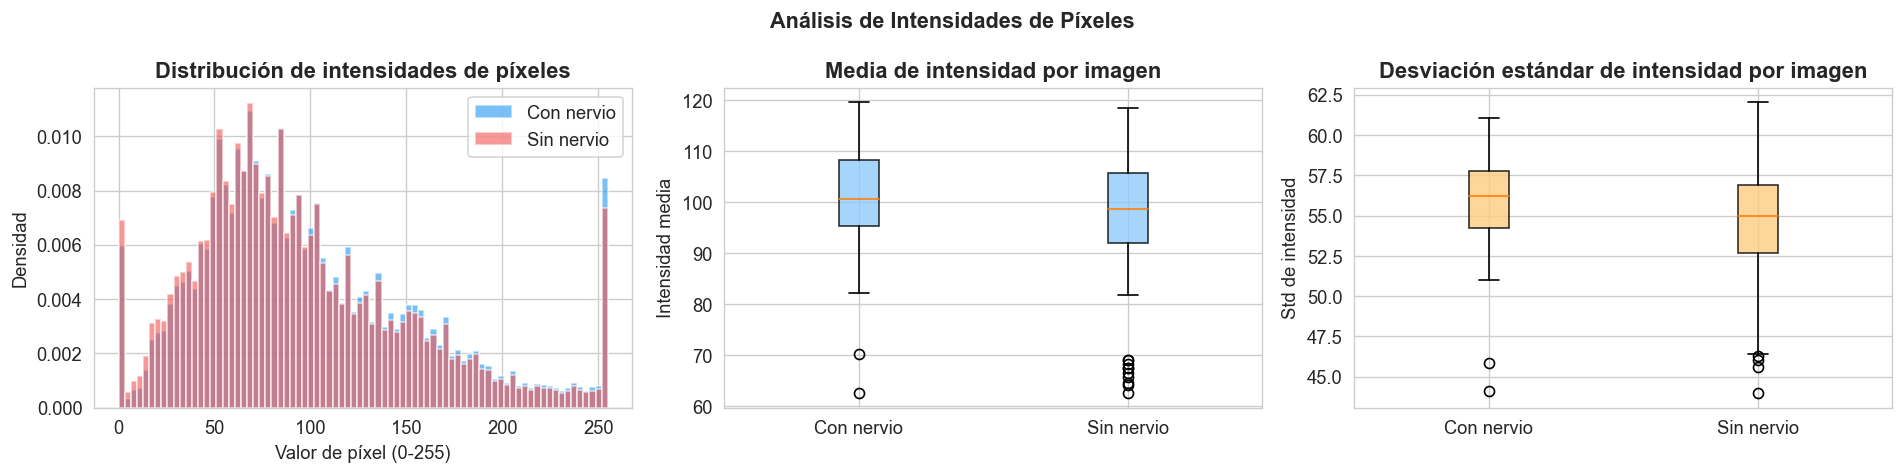


Media global (con nervio)   : 100.61 ± 56.86
Media global (sin nervio)   : 96.81 ± 56.10


In [17]:
# ─── Histogramas de intensidad: con nervio vs sin nervio ─────────────────────
print('Calculando estadísticas de intensidad (muestra de 200 imágenes)...')

sample_with    = df[df['nerve_present'] == 1].sample(min(100, n_with), random_state=SEED)
sample_without = df[df['nerve_present'] == 0].sample(min(100, n_without), random_state=SEED)

def get_pixel_stats(rows_df):
    all_pixels = []
    means, stds = [], []
    for _, row in rows_df.iterrows():
        img = tifffile.imread(str(row['img_path'])).astype(np.float32)
        all_pixels.extend(img.flatten().tolist())
        means.append(img.mean())
        stds.append(img.std())
    return np.array(all_pixels), np.array(means), np.array(stds)

px_nerve, m_nerve, s_nerve     = get_pixel_stats(sample_with)
px_no_nerve, m_no_nerve, s_no_nerve = get_pixel_stats(sample_without)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma global
axes[0].hist(px_nerve[::10], bins=80, alpha=0.6, color='#2196F3', label='Con nervio', density=True)
axes[0].hist(px_no_nerve[::10], bins=80, alpha=0.6, color='#EF5350', label='Sin nervio', density=True)
axes[0].set_title('Distribución de intensidades de píxeles', fontweight='bold')
axes[0].set_xlabel('Valor de píxel (0-255)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Boxplot de media por imagen
axes[1].boxplot([m_nerve, m_no_nerve], labels=['Con nervio', 'Sin nervio'],
                patch_artist=True,
                boxprops=dict(facecolor='#90CAF9', alpha=0.8))
axes[1].set_title('Media de intensidad por imagen', fontweight='bold')
axes[1].set_ylabel('Intensidad media')

# Boxplot de std por imagen
axes[2].boxplot([s_nerve, s_no_nerve], labels=['Con nervio', 'Sin nervio'],
                patch_artist=True,
                boxprops=dict(facecolor='#FFCC80', alpha=0.8))
axes[2].set_title('Desviación estándar de intensidad por imagen', fontweight='bold')
axes[2].set_ylabel('Std de intensidad')

plt.suptitle('Análisis de Intensidades de Píxeles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMedia global (con nervio)   : {px_nerve.mean():.2f} ± {px_nerve.std():.2f}')
print(f'Media global (sin nervio)   : {px_no_nerve.mean():.2f} ± {px_no_nerve.std():.2f}')

In [18]:
# ─── Estadísticas de normalización (solo sobre train) ─────────────────────────
print('Calculando media y std del conjunto de TRAIN (para normalización)...')
train_df = df[df['split'] == 'train']

train_means, train_stds = [], []
for _, row in train_df.iterrows():
    img = tifffile.imread(str(row['img_path'])).astype(np.float32) / 255.0
    train_means.append(img.mean())
    train_stds.append(img.std())

NORM_MEAN = np.mean(train_means)
NORM_STD  = np.mean(train_stds)

print(f'\n Parámetros de normalización (calculados solo en TRAIN):')
print(f'   mean = {NORM_MEAN:.4f}')
print(f'   std  = {NORM_STD:.4f}')
print(f'\n Estos valores se usarán para normalizar train, val y test.')

Calculando media y std del conjunto de TRAIN (para normalización)...

 Parámetros de normalización (calculados solo en TRAIN):
   mean = 0.3877
   std  = 0.2181

 Estos valores se usarán para normalizar train, val y test.


Comparación visual: imagen original vs CLAHE


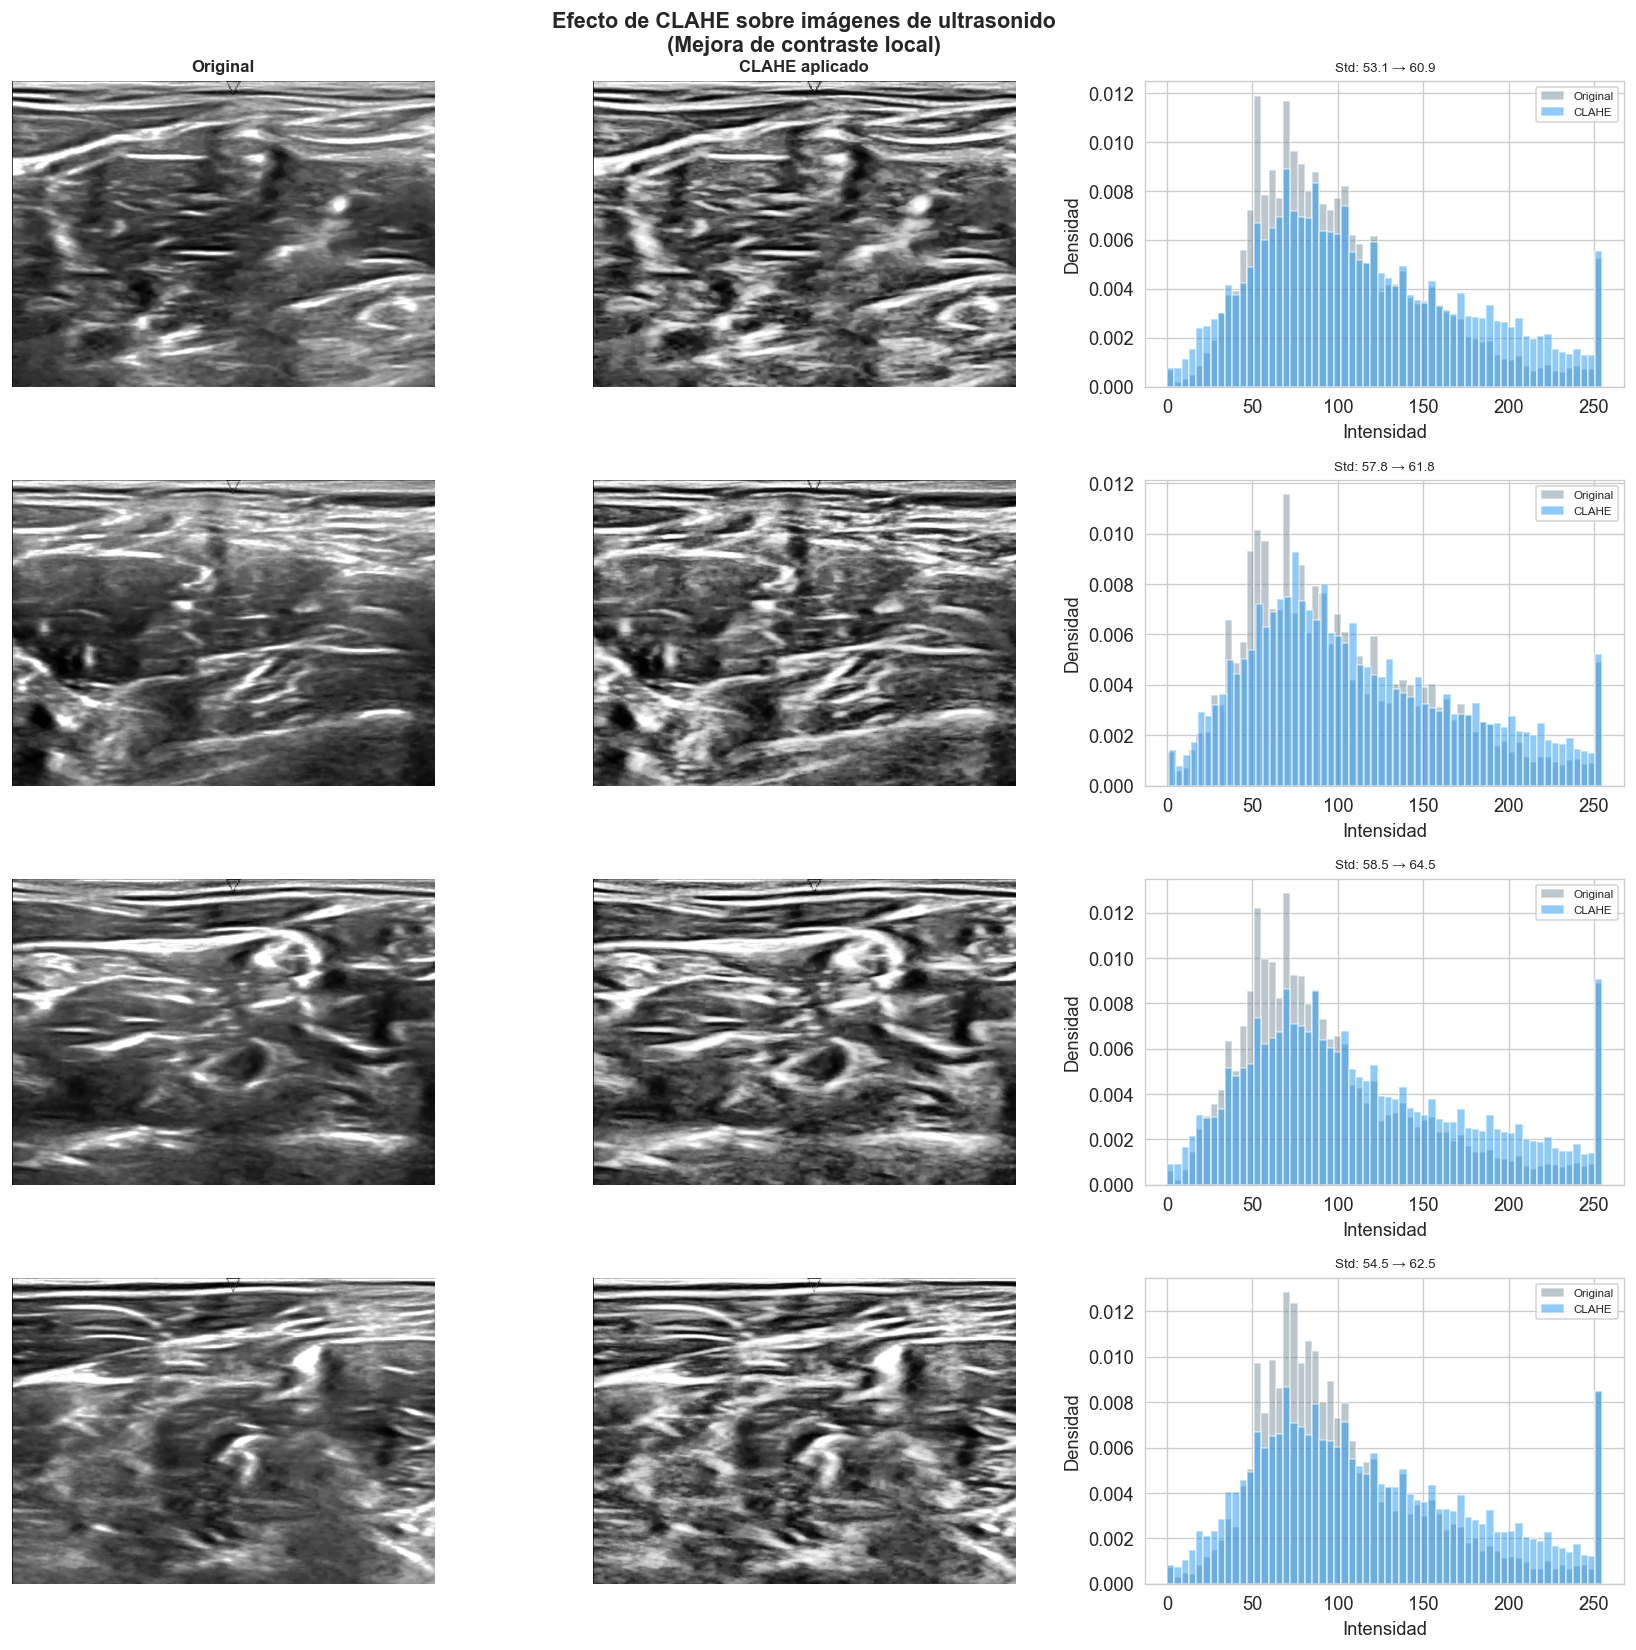


 CLAHE mejora el contraste local sin alterar la escala global.
   clipLimit=2.0 y tileGridSize=(8,8) son valores estándar para ultrasonido.
   Se aplicará SOLO sobre el conjunto de train para evitar data leakage.


In [19]:
# ─── CLAHE: justificación visual del preprocesamiento de contraste ────────────
print('Comparación visual: imagen original vs CLAHE')

# Seleccionar 4 muestras variadas (2 con nervio, 2 sin nervio)
samples = pd.concat([
    df[df['nerve_present'] == 1].sample(2, random_state=SEED),
    df[df['nerve_present'] == 0].sample(2, random_state=SEED)
]).reset_index(drop=True)

# Configurar CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
fig.suptitle('Efecto de CLAHE sobre imágenes de ultrasonido\n(Mejora de contraste local)',
             fontsize=13, fontweight='bold')

col_titles = ['Original', 'CLAHE aplicado', 'Histograma comparado']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=10)

for i, (_, row) in enumerate(samples.iterrows()):
    img = tifffile.imread(str(row['img_path']))

    # Asegurarse que sea uint8
    if img.dtype != np.uint8:
        img = (img / img.max() * 255).astype(np.uint8)

    img_clahe = clahe.apply(img)
    label = 'CON nervio' if row['nerve_present'] == 1 else 'SIN nervio'

    # Original
    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_ylabel(f'{row["stem"]}\n[{label}]', fontsize=8)
    axes[i, 0].axis('off')

    # CLAHE
    axes[i, 1].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].axis('off')

    # Histograma superpuesto
    axes[i, 2].hist(img.flatten(), bins=60, alpha=0.5, color='#78909C',
                    density=True, label='Original')
    axes[i, 2].hist(img_clahe.flatten(), bins=60, alpha=0.5, color='#2196F3',
                    density=True, label='CLAHE')
    axes[i, 2].set_xlabel('Intensidad')
    axes[i, 2].set_ylabel('Densidad')
    axes[i, 2].legend(fontsize=7)

    # Métricas de contraste
    contrast_orig  = img.std()
    contrast_clahe = img_clahe.std()
    axes[i, 2].set_title(f'Std: {contrast_orig:.1f} → {contrast_clahe:.1f}', fontsize=8)

plt.tight_layout()
plt.show()

print('\n CLAHE mejora el contraste local sin alterar la escala global.')
print('   clipLimit=2.0 y tileGridSize=(8,8) son valores estándar para ultrasonido.')
print('   Se aplicará SOLO sobre el conjunto de train para evitar data leakage.')

### Decisiones derivadas — Intensidades

| | |
|---|---|
| **Decisión de preprocesamiento** | Normalización z-score con media y std calculados **exclusivamente sobre train**. Aplicar a train, val y test. |
| **Impacto en arquitectura** | Las imágenes de ultrasonido tienen bajo contraste y alto ruido speckle. Considerar CLAHE como paso de mejora de contraste previo al resize. |
| **Riesgos / Data leakage** | Calcular normalización sobre todo el dataset (incluyendo val/test) introduce leakage estadístico. Parámetros guardados en `NORM_MEAN` y `NORM_STD` arriba. |

### 3.4 Análisis de las Máscaras

Construyendo heatmap acumulado de máscaras...


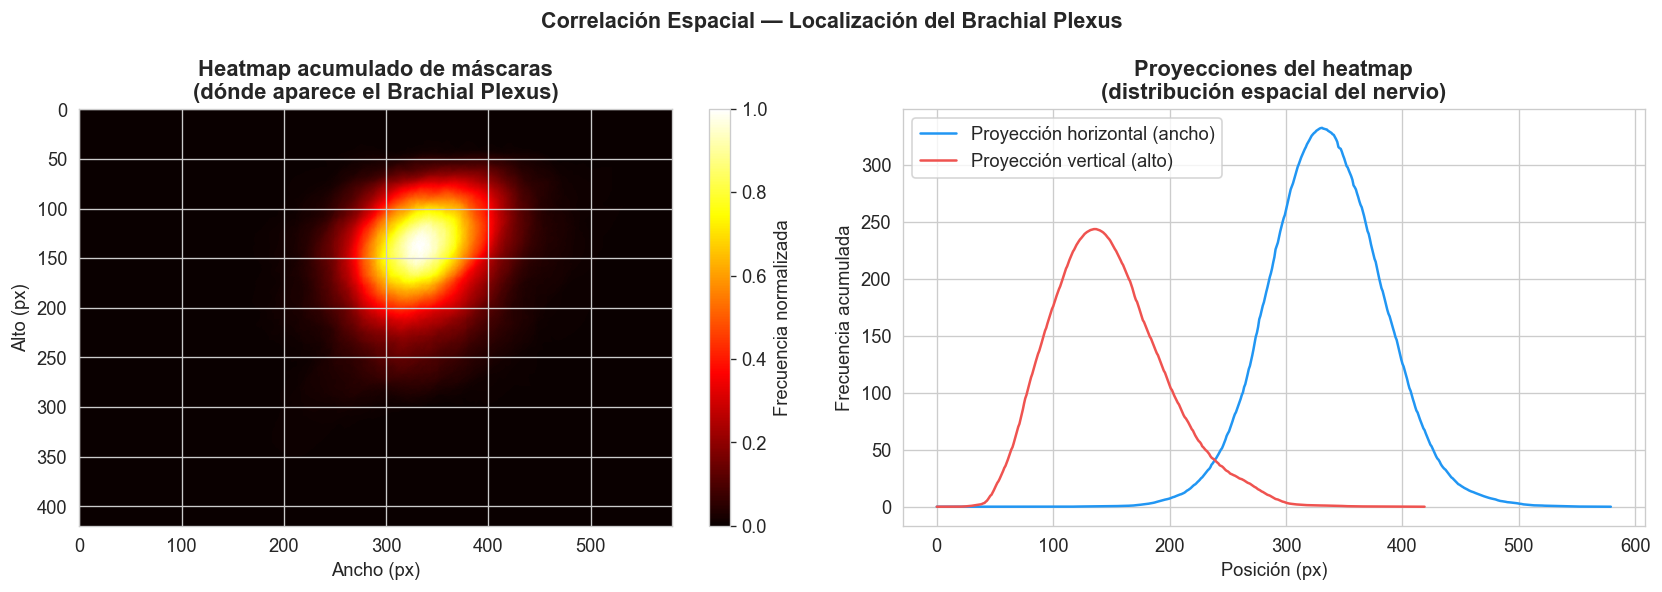

In [20]:
# ─── Distribución espacial del nervio (heatmap acumulado) ────────────────────
print('Construyendo heatmap acumulado de máscaras...')

nerve_df = df[df['nerve_present'] == 1]
heatmap  = np.zeros((420, 580), dtype=np.float32)  # resolución original

for _, row in nerve_df.iterrows():
    mask = tifffile.imread(str(row['mask_path'])).astype(np.float32)
    if mask.shape == (420, 580):
        heatmap += (mask > 0).astype(np.float32)

heatmap_norm = heatmap / heatmap.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(heatmap_norm, cmap='hot', aspect='auto')
axes[0].set_title('Heatmap acumulado de máscaras\n(dónde aparece el Brachial Plexus)', fontweight='bold')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Alto (px)')
plt.colorbar(im, ax=axes[0], label='Frecuencia normalizada')

# Proyección horizontal y vertical
axes[1].plot(heatmap.mean(axis=0), label='Proyección horizontal (ancho)', color='#2196F3')
axes[1].plot(heatmap.mean(axis=1), label='Proyección vertical (alto)', color='#EF5350')
axes[1].set_title('Proyecciones del heatmap\n(distribución espacial del nervio)', fontweight='bold')
axes[1].set_xlabel('Posición (px)')
axes[1].set_ylabel('Frecuencia acumulada')
axes[1].legend()

plt.suptitle('Correlación Espacial — Localización del Brachial Plexus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

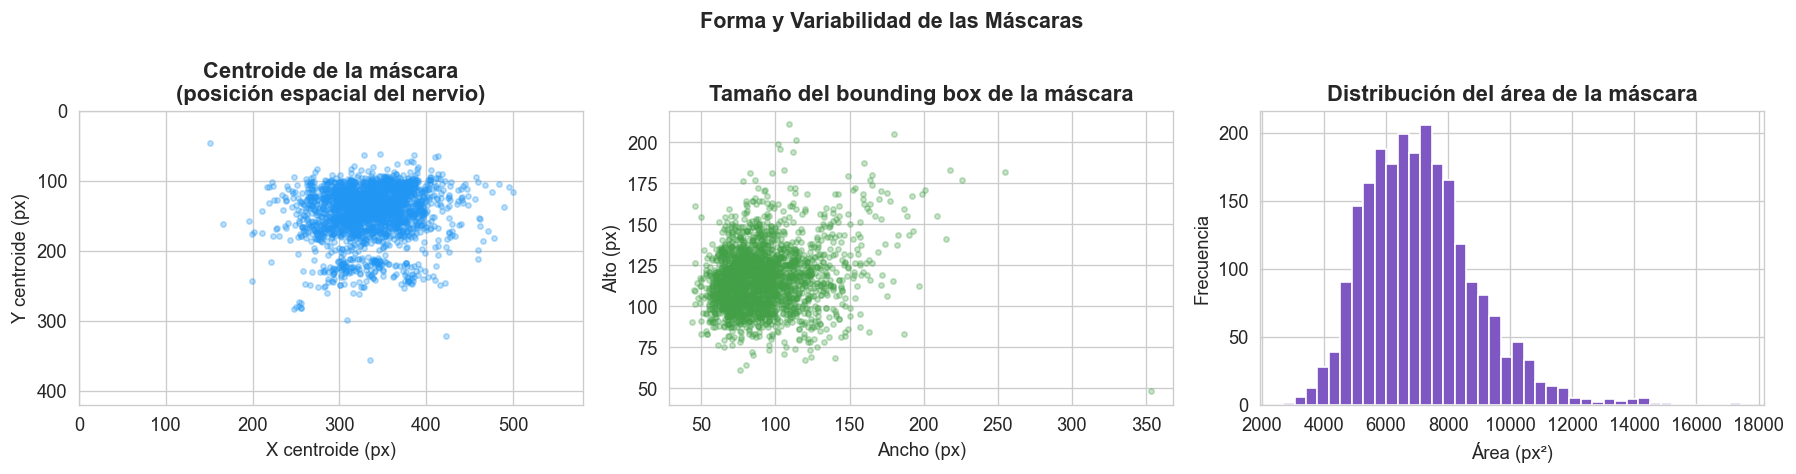

Estadísticas del bounding box:
            w       h      cx      cy     area
count  2323.0  2323.0  2323.0  2323.0   2323.0
mean     91.4   116.8   334.3   145.1   7125.7
std      25.9    18.8    41.9    36.3   1785.0
min      44.0    48.0   150.5    46.1   2684.0
25%      73.0   104.0   307.1   120.2   5806.0
50%      87.0   116.0   333.4   138.1   6976.0
75%     104.0   127.0   363.3   162.2   8120.0
max     353.0   211.0   499.3   356.3  17439.0


In [21]:
# ─── Forma y variabilidad de las máscaras ────────────────────────────────────
nerve_data = df[df['nerve_present'] == 1].copy()

# Calcular bounding box de cada máscara
bbox_info = []
for _, row in nerve_data.iterrows():
    mask = tifffile.imread(str(row['mask_path']))
    ys, xs = np.where(mask > 0)
    if len(xs) > 0:
        bbox_info.append({
            'w': xs.max() - xs.min(),
            'h': ys.max() - ys.min(),
            'cx': xs.mean(),
            'cy': ys.mean(),
            'area': row['mask_area']
        })

bbox_df = pd.DataFrame(bbox_info)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(bbox_df['cx'], bbox_df['cy'], alpha=0.3, s=10, color='#2196F3')
axes[0].set_xlim(0, 580)
axes[0].set_ylim(420, 0)
axes[0].set_title('Centroide de la máscara\n(posición espacial del nervio)', fontweight='bold')
axes[0].set_xlabel('X centroide (px)')
axes[0].set_ylabel('Y centroide (px)')

axes[1].scatter(bbox_df['w'], bbox_df['h'], alpha=0.3, s=10, color='#43A047')
axes[1].set_title('Tamaño del bounding box de la máscara', fontweight='bold')
axes[1].set_xlabel('Ancho (px)')
axes[1].set_ylabel('Alto (px)')

axes[2].hist(bbox_df['area'], bins=40, color='#7E57C2', edgecolor='white')
axes[2].set_title('Distribución del área de la máscara', fontweight='bold')
axes[2].set_xlabel('Área (px²)')
axes[2].set_ylabel('Frecuencia')

plt.suptitle('Forma y Variabilidad de las Máscaras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas del bounding box:')
print(bbox_df[['w','h','cx','cy','area']].describe().round(1).to_string())

### Decisiones derivadas — Análisis de Máscaras

| | |
|---|---|
| **Decisión de preprocesamiento** | El nervio tiende a aparecer en regiones específicas de la imagen. Esto justifica mantener la información espacial completa (sin cropping agresivo). |
| **Impacto en arquitectura** | Alta variabilidad en posición y tamaño del nervio justifica el uso de skip connections de U-Net para preservar información espacial a múltiples escalas. |
| **Riesgos / Data leakage** | Ninguno en esta etapa. |

---
## 4. Resumen Ejecutivo y Decisiones Finales

In [22]:
print('=' * 65)
print('RESUMEN EJECUTIVO DEL EDA')
print('=' * 65)

print(f"""
1. DATASET
   - {len(df):,} imágenes de entrenamiento | {len(all_test_files):,} de test
   - {df['patient_id'].nunique()} pacientes únicos
   - Resolución uniforme: 580×420 px, escala de grises, sin corruptos

2. DESBALANCE
   - Con nervio  : {n_with:,} ({100*n_with/len(df):.1f}%)
   - Sin nervio  : {n_without:,} ({100*n_without/len(df):.1f}%)
   - Ratio       : {ratio:.2f}:1 → Usar Dice Loss + detección de presencia

3. SPLIT (por paciente, sin leakage)
   - Train : {len(p_train)} pacientes
   - Val   : {len(p_val)} pacientes
   - Test  : {len(p_test)} pacientes

4. NORMALIZACIÓN (calculada solo en train)
   - mean = {NORM_MEAN:.4f}  |  std = {NORM_STD:.4f}

5. DECISIONES DE ARQUITECTURA
   - U-Net con skip connections (variabilidad espacial de la máscara)
   - Dual-head: segmentación (Dice) + presencia (BCE)
   - Resize a 256×256 con interpolación bilinear (imagen) y nearest (máscara)
   - Data augmentation: flips, rotaciones, ruido gaussian (speckle)
""")
print('=' * 65)

RESUMEN EJECUTIVO DEL EDA

1. DATASET
   - 5,635 imágenes de entrenamiento | 5,508 de test
   - 47 pacientes únicos
   - Resolución uniforme: 580×420 px, escala de grises, sin corruptos

2. DESBALANCE
   - Con nervio  : 2,323 (41.2%)
   - Sin nervio  : 3,312 (58.8%)
   - Ratio       : 1.43:1 → Usar Dice Loss + detección de presencia

3. SPLIT (por paciente, sin leakage)
   - Train : 32 pacientes
   - Val   : 7 pacientes
   - Test  : 8 pacientes

4. NORMALIZACIÓN (calculada solo en train)
   - mean = 0.3877  |  std = 0.2181

5. DECISIONES DE ARQUITECTURA
   - U-Net con skip connections (variabilidad espacial de la máscara)
   - Dual-head: segmentación (Dice) + presencia (BCE)
   - Resize a 256×256 con interpolación bilinear (imagen) y nearest (máscara)
   - Data augmentation: flips, rotaciones, ruido gaussian (speckle)



In [23]:
# ─── Guardar el DataFrame procesado para uso en el pipeline de modelado ───────
out_path = DATA_DIR / 'df_eda_processed.csv'
df[['stem', 'patient_id', 'frame_id', 'nerve_present', 'mask_area', 'split']].to_csv(out_path, index=False)
print(f' DataFrame guardado en: {out_path}')
print(f'   Columnas: {list(df.columns)}')

# Guardar parámetros de normalización
norm_params = pd.DataFrame({'mean': [NORM_MEAN], 'std': [NORM_STD]})
norm_params.to_csv(DATA_DIR / 'norm_params.csv', index=False)
print(f' Parámetros de normalización guardados en: {DATA_DIR}/norm_params.csv')

 DataFrame guardado en: C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation\df_eda_processed.csv
   Columnas: ['img_path', 'mask_path', 'patient_id', 'frame_id', 'stem', 'mask_area', 'nerve_present', 'split']
 Parámetros de normalización guardados en: C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation/norm_params.csv


=== Estructura de train_masks.csv ===
Shape: (5635, 3)
Columnas: ['subject', 'img', 'pixels']

Primeras filas:


,subject,img,pixels
0,1,1,168153 9 168570 15 168984 22 169401 26 169818 ...
1,1,2,96346 7 96762 16 97179 27 97595 35 98012 40 98...
2,1,3,121957 2 122365 26 122784 28 123202 31 123618 ...
3,1,4,110980 9 111393 21 111810 33 112228 43 112647 ...
4,1,5,NaN
5,1,6,NaN
6,1,7,172767 15 173175 29 173591 34 173993 7 174004 ...
7,1,8,NaN



=== Conteo según train_masks.csv ===
Con nervio (RLE no vacío) : 2,323  (41.2%)
Sin nervio (RLE vacío)    : 3,312  (58.8%)

=== Conteo según cálculo pixel-wise (nuestro EDA) ===
Con nervio : 2,323  (41.2%)
Sin nervio : 3,312  (58.8%)

 Ambos métodos coinciden perfectamente — dataset íntegro.


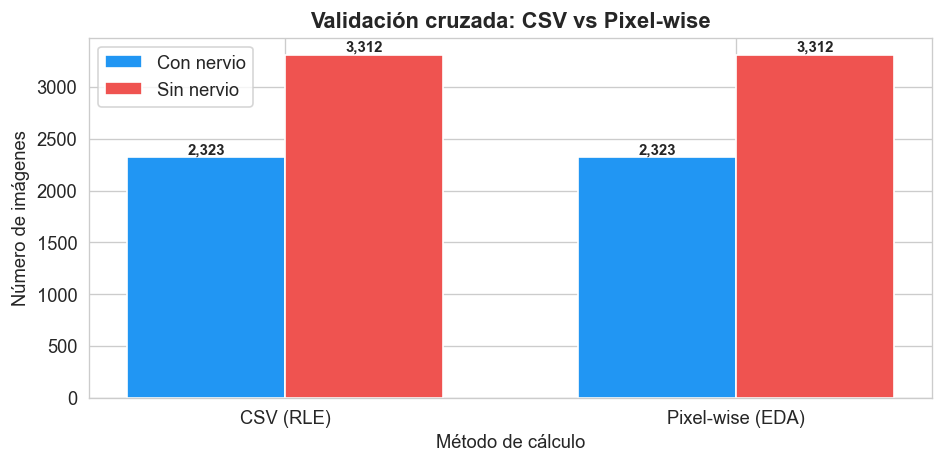

In [24]:
# ═════════════════════════════════════════════════════════════════════
# VALIDACIÓN CRUZADA CON train_masks.csv
# Verificar consistencia entre el RLE encoding del CSV y nuestro
# cálculo pixel-wise de las máscaras
# ═════════════════════════════════════════════════════════════════════

masks_csv = pd.read_csv(MASKS_CSV)

print('=== Estructura de train_masks.csv ===')
print(f'Shape: {masks_csv.shape}')
print(f'Columnas: {list(masks_csv.columns)}')
print(f'\nPrimeras filas:')
display(masks_csv.head(8))

# ─── Identificar máscaras vacías en el CSV ───────────────────────────
# Las máscaras vacías tienen 'pixels' como NaN o string vacío
masks_csv['is_empty'] = masks_csv['pixels'].isna() | (masks_csv['pixels'].astype(str).str.strip() == '')

n_empty_csv    = int(masks_csv['is_empty'].sum())
n_nonempty_csv = int((~masks_csv['is_empty']).sum())

print(f'\n=== Conteo según train_masks.csv ===')
print(f'Con nervio (RLE no vacío) : {n_nonempty_csv:,}  ({100*n_nonempty_csv/len(masks_csv):.1f}%)')
print(f'Sin nervio (RLE vacío)    : {n_empty_csv:,}  ({100*n_empty_csv/len(masks_csv):.1f}%)')

print(f'\n=== Conteo según cálculo pixel-wise (nuestro EDA) ===')
print(f'Con nervio : {n_with:,}  ({100*n_with/len(df):.1f}%)')
print(f'Sin nervio : {n_without:,}  ({100*n_without/len(df):.1f}%)')

# ─── Verificación de consistencia ─────────────────────────────────────
diff = abs(n_nonempty_csv - n_with)
if diff == 0:
    print(f'\n Ambos métodos coinciden perfectamente — dataset íntegro.')
else:
    print(f'\n Discrepancia de {diff} imágenes entre métodos.')
    print('   Revisar manualmente los casos inconsistentes.')

# ─── Visualización comparativa ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
methods = ['CSV (RLE)', 'Pixel-wise (EDA)']
con_nervio = [n_nonempty_csv, n_with]
sin_nervio = [n_empty_csv, n_without]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, con_nervio, width, label='Con nervio', color='#2196F3')
bars2 = ax.bar(x + width/2, sin_nervio, width, label='Sin nervio', color='#EF5350')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Método de cálculo')
ax.set_ylabel('Número de imágenes')
ax.set_title('Validación cruzada: CSV vs Pixel-wise', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
plt.tight_layout()
plt.show()

Comparación visual: imagen original vs CLAHE



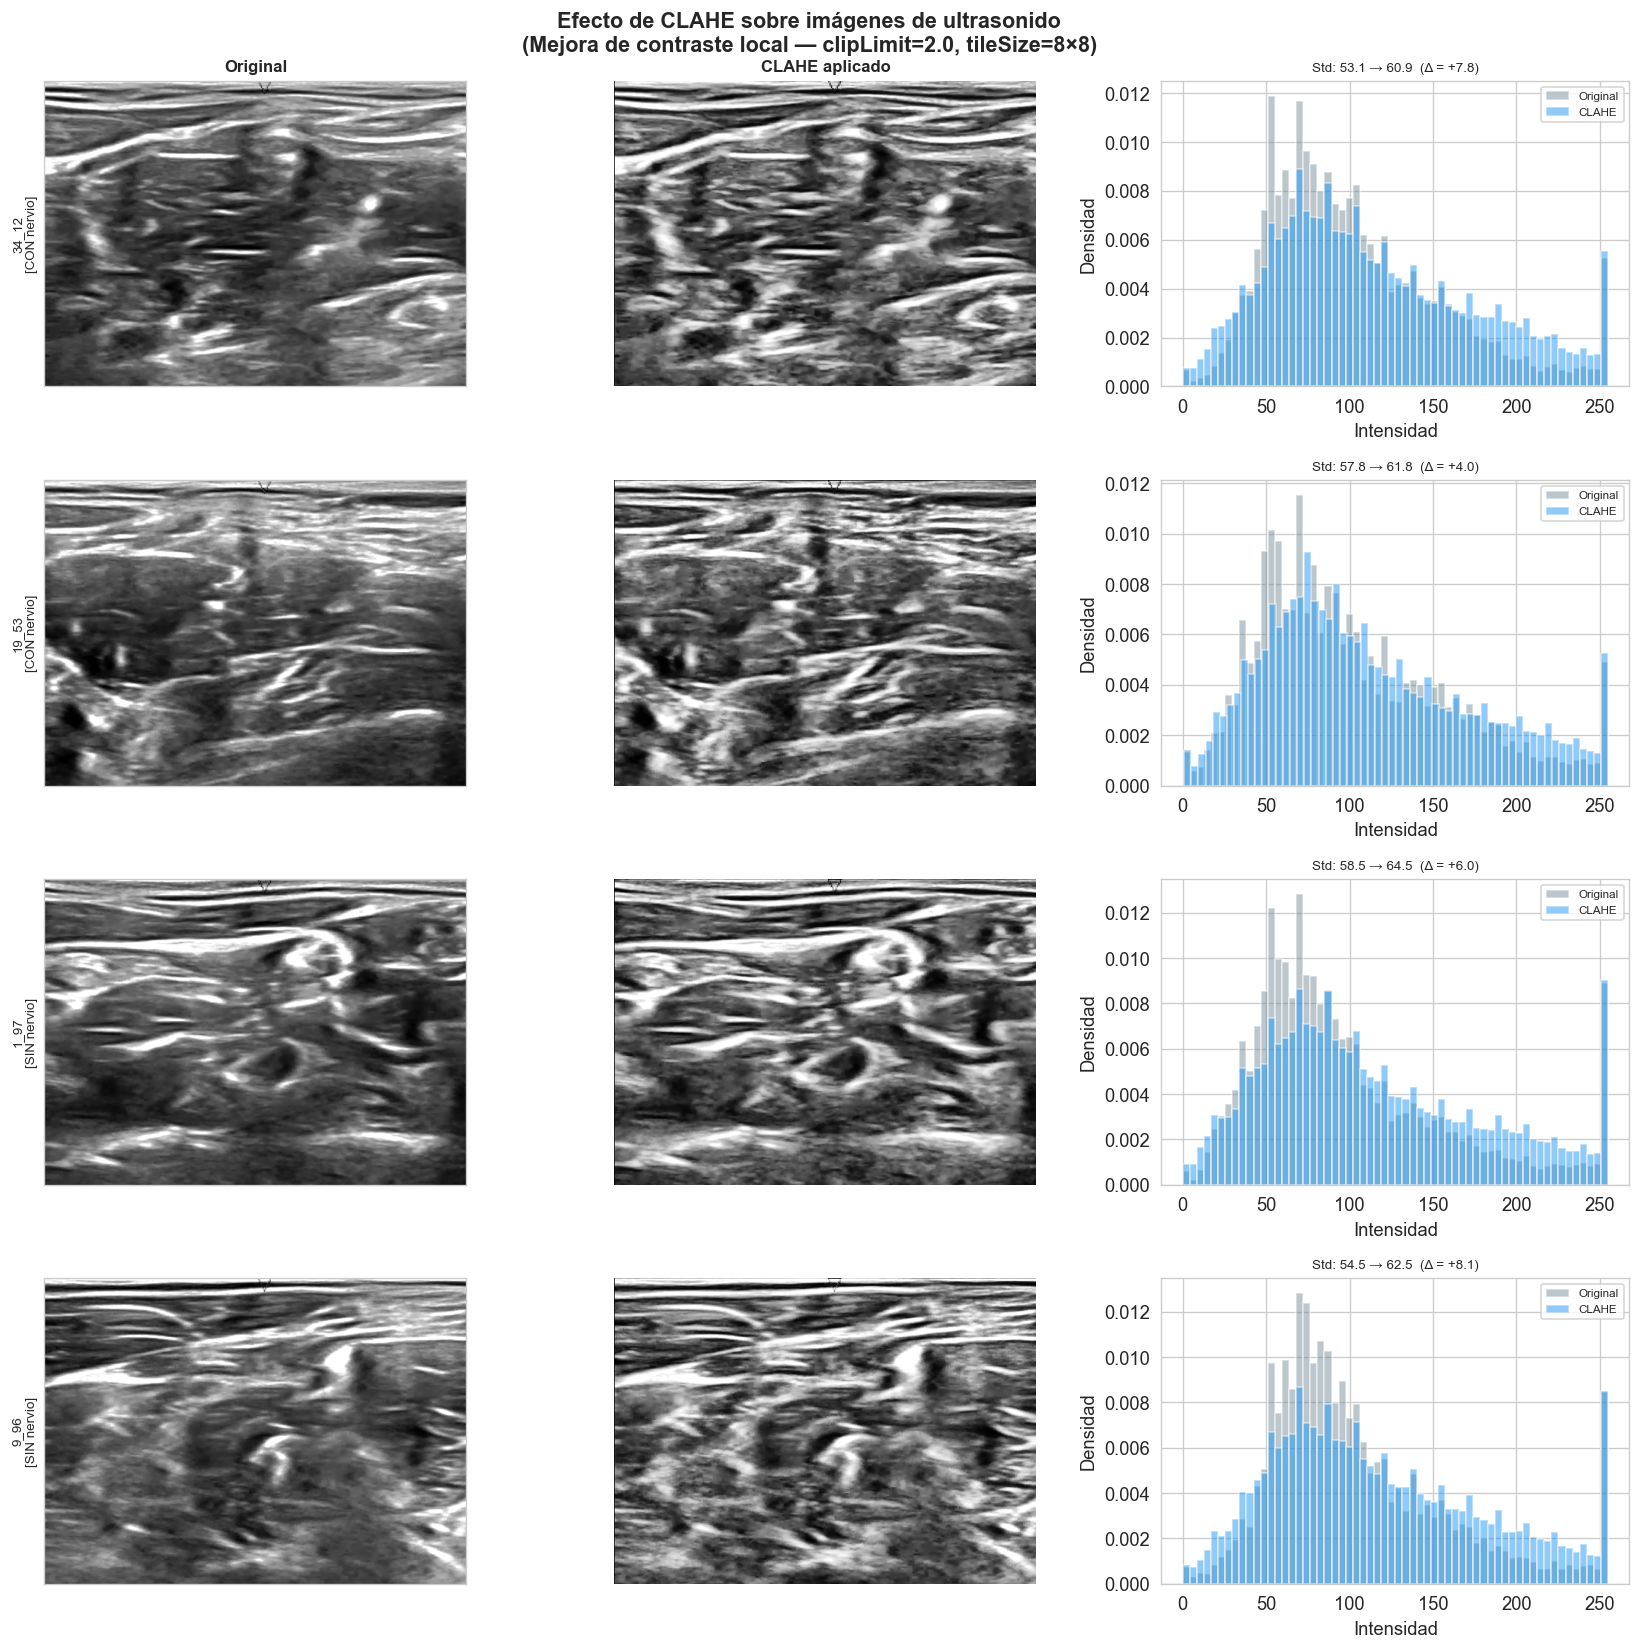


 Justificación de uso de CLAHE:
   • Las imágenes de ultrasonido tienen bajo contraste y alto ruido speckle
   • CLAHE mejora el contraste local sin alterar la escala global
   • clipLimit=2.0 evita amplificación excesiva del ruido
   • tileGridSize=(8,8) preserva detalles finos de la anatomía
   • Se aplicará en el pipeline de modelado antes del z-score


In [25]:
# ═════════════════════════════════════════════════════════════════════
# CLAHE — Justificación visual del preprocesamiento de contraste
# Comparación antes/después + impacto en histogramas
# ═════════════════════════════════════════════════════════════════════

print('Comparación visual: imagen original vs CLAHE\n')

# Seleccionar 4 muestras: 2 con nervio + 2 sin nervio
samples = pd.concat([
    df[df['nerve_present'] == 1].sample(2, random_state=SEED),
    df[df['nerve_present'] == 0].sample(2, random_state=SEED)
]).reset_index(drop=True)

# Configurar CLAHE (parámetros estándar para ultrasonido)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
fig.suptitle('Efecto de CLAHE sobre imágenes de ultrasonido\n'
             '(Mejora de contraste local — clipLimit=2.0, tileSize=8×8)',
             fontsize=13, fontweight='bold')

col_titles = ['Original', 'CLAHE aplicado', 'Histogramas comparados']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=10)

for i, (_, row) in enumerate(samples.iterrows()):
    img = tifffile.imread(str(row['img_path']))

    # Asegurar uint8
    if img.dtype != np.uint8:
        img = (img / max(img.max(), 1) * 255).astype(np.uint8)

    img_clahe = clahe.apply(img)
    label = 'CON nervio' if row['nerve_present'] == 1 else 'SIN nervio'

    # Original
    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_ylabel(f'{row["stem"]}\n[{label}]', fontsize=8)
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

    # CLAHE
    axes[i, 1].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].axis('off')

    # Histograma superpuesto
    axes[i, 2].hist(img.flatten(), bins=60, alpha=0.5, color='#78909C',
                    density=True, label='Original')
    axes[i, 2].hist(img_clahe.flatten(), bins=60, alpha=0.5, color='#2196F3',
                    density=True, label='CLAHE')
    axes[i, 2].set_xlabel('Intensidad')
    axes[i, 2].set_ylabel('Densidad')
    axes[i, 2].legend(fontsize=7)

    # Métricas de contraste
    contrast_orig  = img.std()
    contrast_clahe = img_clahe.std()
    delta = contrast_clahe - contrast_orig
    axes[i, 2].set_title(f'Std: {contrast_orig:.1f} → {contrast_clahe:.1f}  '
                          f'(Δ = {delta:+.1f})',
                          fontsize=8)

plt.tight_layout()
plt.show()

print('\n Justificación de uso de CLAHE:')
print('   • Las imágenes de ultrasonido tienen bajo contraste y alto ruido speckle')
print('   • CLAHE mejora el contraste local sin alterar la escala global')
print('   • clipLimit=2.0 evita amplificación excesiva del ruido')
print('   • tileGridSize=(8,8) preserva detalles finos de la anatomía')
print('   • Se aplicará en el pipeline de modelado antes del z-score')

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── Tabla 1: Resumen del dataset ────────────────────────────────────────────
dataset_summary = pd.DataFrame({
    'Característica': [
        'Total imágenes (train)',
        'Total imágenes (test)',
        'Pacientes únicos',
        'Resolución original',
        'Tipo de imagen',
        'Imágenes con nervio',
        'Imágenes sin nervio',
        'Ratio desbalance (sin/con)',
        'Pares contradictorios (SSIM > 0.90)',
        'Imágenes corruptas',
    ],
    'Valor': [
        '5,635',
        '5,508',
        '47',
        '580 × 420 px',
        'Escala de grises (1 canal)',
        f'{n_with:,} ({100*n_with/len(df):.1f}%)',
        f'{n_without:,} ({100*n_without/len(df):.1f}%)',
        f'{ratio:.2f}:1',
        '33 pares en 19/47 pacientes (2 con SSIM=1.0)',
        '0',
    ],
    'Fuente EDA': [
        'Sección 1',
        'Sección 1',
        'Sección 1',
        'Sección 3.2',
        'Sección 3.2',
        'Sección 2.1',
        'Sección 2.1',
        'Sección 2.1',
        'Sección 2.2',
        'Sección 2.2',
    ]
})

print('=' * 70)
print('TABLA 1 — RESUMEN DEL DATASET')
print('=' * 70)
print(dataset_summary.to_string(index=False))

TABLA 1 — RESUMEN DEL DATASET
                     Característica                                        Valor  Fuente EDA
             Total imágenes (train)                                        5,635   Sección 1
              Total imágenes (test)                                        5,508   Sección 1
                   Pacientes únicos                                           47   Sección 1
                Resolución original                                 580 × 420 px Sección 3.2
                     Tipo de imagen                   Escala de grises (1 canal) Sección 3.2
                Imágenes con nervio                                2,323 (41.2%) Sección 2.1
                Imágenes sin nervio                                3,312 (58.8%) Sección 2.1
         Ratio desbalance (sin/con)                                       1.43:1 Sección 2.1
Pares contradictorios (SSIM > 0.90) 33 pares en 19/47 pacientes (2 con SSIM=1.0) Sección 2.2
                 Imágenes corruptas     

In [27]:
# ─── Tabla 2: Partición del dataset ──────────────────────────────────────────
split_summary = df.groupby('split').agg(
    Frames     = ('stem', 'count'),
    Pacientes  = ('patient_id', 'nunique'),
    Tasa_nervio = ('nerve_present', 'mean')
).reindex(['train', 'val', 'test'])

split_summary['Frames (%)'] = (split_summary['Frames'] / len(df) * 100).round(1)
split_summary['Tasa_nervio'] = split_summary['Tasa_nervio'].round(3)
split_summary.columns = ['Frames', 'Pacientes', 'Tasa nervio', 'Frames (%)']

# Verificar anti-leakage
train_p = set(df[df['split']=='train']['patient_id'])
val_p   = set(df[df['split']=='val']['patient_id'])
test_p  = set(df[df['split']=='test']['patient_id'])

print('=' * 70)
print('TABLA 2 — PARTICIÓN DEL DATASET (split por paciente)')
print('=' * 70)
print(split_summary.to_string())
print(f'\nVerificación anti-leakage:')
print(f'  Overlap train ∩ val  : {len(train_p & val_p)} pacientes  ✓' if not (train_p & val_p) else '  LEAKAGE DETECTADO')
print(f'  Overlap train ∩ test : {len(train_p & test_p)} pacientes  ✓' if not (train_p & test_p) else '  LEAKAGE DETECTADO')
print(f'  Overlap val ∩ test   : {len(val_p & test_p)} pacientes  ✓' if not (val_p & test_p) else '  LEAKAGE DETECTADO')

TABLA 2 — PARTICIÓN DEL DATASET (split por paciente)
       Frames  Pacientes  Tasa nervio  Frames (%)
split                                            
train    3836         32        0.439        68.1
val       839          7        0.371        14.9
test      960          8        0.343        17.0

Verificación anti-leakage:
  Overlap train ∩ val  : 0 pacientes  ✓
  Overlap train ∩ test : 0 pacientes  ✓
  Overlap val ∩ test   : 0 pacientes  ✓


In [30]:
# ─── Tabla 3: Decisiones de preprocesamiento ─────────────────────────────────
decisions = [
    {
        'Aspecto': 'Desbalance de clases',
        'Observación EDA': f'60.2% sin nervio, ratio {ratio:.2f}:1',
        'Decisión': 'Dice Loss suavizado (smooth=1) + rama de presencia dual-head',
        'Riesgo evitado': 'No aplicar resampling (evita leakage estadístico)',
        'Sección': '2.1'
    },
    {
        'Aspecto': 'Etiquetas contradictorias',
        'Observación EDA': '33 pares SSIM>0.90, 2 pares SSIM=1.0',
        'Decisión': 'Conservar todos los datos + Dice Loss smooth=1 (robusto ante ruido)',
        'Riesgo evitado': 'Filtrar contradictorios ANTES del split, no después',
        'Sección': '2.2'
    },
    {
        'Aspecto': 'Split del dataset',
        'Observación EDA': '47 pacientes; frames del mismo paciente altamente correlacionados',
        'Decisión': 'Split 70/15/15 por paciente completo, estratificado por presencia de nervio',
        'Riesgo evitado': 'Split aleatorio por frame = data leakage garantizado',
        'Sección': '2.4'
    },
    {
        'Aspecto': 'Normalización',
        'Observación EDA': f'NORM_MEAN={NORM_MEAN:.4f}, NORM_STD={NORM_STD:.4f}',
        'Decisión': 'Z-score calculado SOLO en train. Aplicar a train/val/test.',
        'Riesgo evitado': 'Calcular sobre todo el dataset = leakage estadístico',
        'Sección': '3.3'
    },
    {
        'Aspecto': 'Resize',
        'Observación EDA': 'Resolución uniforme 580×420 px, relación 4:3',
        'Decisión': 'Resize a 256×256: INTER_LINEAR (imagen), INTER_NEAREST (máscara)',
        'Riesgo evitado': 'INTER_LINEAR en máscara crea valores intermedios no binarios',
        'Sección': '3.2'
    },
    {
        'Aspecto': 'Contraste',
        'Observación EDA': 'Bajo contraste local, alto ruido speckle en ultrasonido',
        'Decisión': 'CLAHE (clipLimit=2.0, tileGrid=8×8) solo en train como augmentation estocástico',
        'Riesgo evitado': 'Aplicar CLAHE en val/test con params de train = leakage de distribución',
        'Sección': '3.3'
    },
    {
        'Aspecto': 'Data augmentation',
        'Observación EDA': 'Solo 3,836 frames de train; nervio aparece en región espacial específica',
        'Decisión': 'HorizontalFlip + Rotate(±15°) + ElasticTransform + GaussNoise + CLAHE',
        'Riesgo evitado': 'Rotaciones >30° destruyen prior espacial del nervio (heatmap sección 3.4)',
        'Sección': '3.3-3.4'
    },
    {
        'Aspecto': 'Arquitectura',
        'Observación EDA': 'Alta variabilidad de posición y tamaño del nervio (bbox sección 3.4)',
        'Decisión': 'U-Net con skip connections (preservar info espacial multi-escala)',
        'Riesgo evitado': 'Arquitecturas sin skip connections pierden localización del target pequeño',
        'Sección': '3.4'
    },
]

dec_df = pd.DataFrame(decisions)
print('=' * 90)
print('TABLA 3 — DECISIONES DE PREPROCESAMIENTO DERIVADAS DEL EDA')
print('=' * 90)
for _, row in dec_df.iterrows():
    print(f'\n  [{row["Sección"]}] {row["Aspecto"].upper()}')
    print(f'       Observación : {row["Observación EDA"]}')
    print(f'       Decisión    : {row["Decisión"]}')
    print(f'       Riesgo      : {row["Riesgo evitado"]}')
print('\n' + '=' * 90)

TABLA 3 — DECISIONES DE PREPROCESAMIENTO DERIVADAS DEL EDA

  [2.1] DESBALANCE DE CLASES
       Observación : 60.2% sin nervio, ratio 1.43:1
       Decisión    : Dice Loss suavizado (smooth=1) + rama de presencia dual-head
       Riesgo      : No aplicar resampling (evita leakage estadístico)

  [2.2] ETIQUETAS CONTRADICTORIAS
       Observación : 33 pares SSIM>0.90, 2 pares SSIM=1.0
       Decisión    : Conservar todos los datos + Dice Loss smooth=1 (robusto ante ruido)
       Riesgo      : Filtrar contradictorios ANTES del split, no después

  [2.4] SPLIT DEL DATASET
       Observación : 47 pacientes; frames del mismo paciente altamente correlacionados
       Decisión    : Split 70/15/15 por paciente completo, estratificado por presencia de nervio
       Riesgo      : Split aleatorio por frame = data leakage garantizado

  [3.3] NORMALIZACIÓN
       Observación : NORM_MEAN=0.3877, NORM_STD=0.2181
       Decisión    : Z-score calculado SOLO en train. Aplicar a train/val/test.
       R

Los siguientes archivos son generados por este notebook y consumidos directamente por `02_models.ipynb` y `03_benchmark.ipynb`:

| Archivo | Columnas / Contenido | Usado en |
|---|---|---|
| `df_eda_processed.csv` | `stem, patient_id, frame_id, nerve_present, mask_area, split` | `02_models.ipynb` |
| `norm_params.csv` | `mean=0.3877, std=0.2181` | `02_models.ipynb` |

```